In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
import time
import pandas as pd
import csv
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

In [ ]:

# Set up Selenium WebDriver
chrome_driver_path = "C:/Users/USER/OneDrive/Desktop/chromewebdriver/chromedriver-win64/chromedriver.exe"
service = Service(chrome_driver_path)
driver = webdriver.Chrome(service=service)

# **STEP 1: LOAD ALL EPISODES**
base_url = "https://app.podscribe.ai/series/359"  # Adjust if necessary
driver.get(base_url)
time.sleep(5)  # Allow page to load

# Click the "Load all episodes" button
try:
    # Locate the button using the inner <span> element
    load_all_button = WebDriverWait(driver, 10).until(
        EC.presence_of_element_located(
            (By.XPATH, "//span[contains(@class, 'MuiTypography-psBodySemibold') and text()='Load all episodes']/ancestor::button")
        )
    )
    load_all_button.click()
    print("Clicked the 'Load all episodes' button.")
    time.sleep(5)  # Wait for all episodes to load
except Exception as e:
    print(f"Error clicking the 'Load all episodes' button: {e}")
    driver.quit()
    exit()

# **STEP 2: SCRAPE ALL EPISODE LINKS**
episode_links = []

# Function to scrape episode links from the current page
def scrape_episode_links():
    try:
        # Wait for episode links to be present
        episodes = WebDriverWait(driver, 10).until(
            EC.presence_of_all_elements_located((By.CSS_SELECTOR, "a[href*='episode']"))
        )
        print(f"Found {len(episodes)} episode links on the current page.")

        for episode in episodes:
            link = episode.get_attribute("href")
            if link and "episode" in link:  
                episode_links.append(link)
    except Exception as e:
        print(f"Error scraping episode links: {e}")

# Scrape episode links from the first page
scrape_episode_links()
print(f"Total episodes found so far: {len(episode_links)}")

# **STEP 3: HANDLE PAGINATION **
while True:
    # Check if there's a "Next" button and click it
    try:
        next_button = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, "button[aria-label='Go to next page']"))
        )
        
        # Check if the button is disabled
        if "Mui-disabled" in next_button.get_attribute("class") or next_button.get_attribute("disabled") is not None:
            print("Reached the last page.")
            break  # Exit the loop if the button is disabled
        
        # Click the "Next" button
        next_button.click()
        print("Clicked the 'Go to next page' button.")
        time.sleep(5)  # Wait for the next page to load

        # Scrape episode links from the new page
        scrape_episode_links()
        print(f"Total episodes found so far: {len(episode_links)}")
    except Exception as e:
        print(f"Error navigating to the next page: {e}")
        break

print(f"Total episodes found: {len(episode_links)}")

# **STEP 4: SCRAPE TRANSCRIPTS FOR ALL EPISODES**
with open("guyraz_transcripts.csv", "w", newline="", encoding="utf-8") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Episode ID", "Episode Name", "Transcript Text"])  # Write header

    for i, url in enumerate(episode_links):
        try:
            driver.get(url)
            time.sleep(5)  # Wait for page to load completely

            # Extract episode title
            try:
                episode_name_element = WebDriverWait(driver, 10).until(
                    EC.presence_of_element_located(
                        (By.XPATH, "//p[contains(@class, 'MuiTypography-root MuiTypography-body1')]")
                    )
                )
                episode_name = episode_name_element.text
            except:
                episode_name = "Unknown"

            # Extract transcript text
            try:
                transcript_container = driver.find_element(By.ID, "transcriptContainerContainer")
                transcript_text = transcript_container.text
            except:
                transcript_text = "Transcript not found"

            # Write data to CSV
            writer.writerow([i + 1, episode_name, transcript_text])
            print(f"Scraped {i+1}/{len(episode_links)}: {episode_name}")

        # except Exception as e:
            print(f"Error scraping episode {i+1}: {e}")

# Close WebDriver
driver.quit()
print("Scraping complete! Transcripts saved to 'guyraz_transcripts.csv'.")

Clicked the 'Load all episodes' button.
Found 25 episode links on the current page.
Total episodes found so far: 25
Clicked the 'Go to next page' button.
Found 25 episode links on the current page.
Total episodes found so far: 50
Clicked the 'Go to next page' button.
Found 25 episode links on the current page.
Total episodes found so far: 75
Clicked the 'Go to next page' button.
Found 25 episode links on the current page.
Total episodes found so far: 100
Clicked the 'Go to next page' button.
Found 25 episode links on the current page.
Total episodes found so far: 125
Clicked the 'Go to next page' button.
Found 25 episode links on the current page.
Total episodes found so far: 150
Clicked the 'Go to next page' button.
Found 25 episode links on the current page.
Total episodes found so far: 175
Clicked the 'Go to next page' button.
Found 25 episode links on the current page.
Total episodes found so far: 200
Clicked the 'Go to next page' button.
Found 25 episode links on the current page.

In [2]:
df = pd.read_csv('guyraz_transcripts.csv')
print(df.head(5))

   Episode ID                                       Episode Name  \
0           1                    PayPal: Max Levchin (June 2022)   
1           2  Advice Line with Lyndon Cormack of Herschel Su...   
2           3        Listen Now: Reclaiming with Monica Lewinsky   
3           9  Advice Line with Vicky Tsai of Tatcha (Septemb...   
4          10  Dogfish Head Craft Brewery: Sam and Mariah Cal...   

                                     Transcript Text  
0  Wondery plus kids in Apple, Podcasts (Ad) wond...  
1  Wondery plus kids in Apple, Podcasts (Ad)  \n0...  
2  Wondery Plus - Reclaiming with Monica Lewinsky...  
3  Wondery plus kids in Apple, Podcasts (Ad)  \n0...  
4  Wondery (Ad) wondery.com \n00:00:00\nWondery P...  


1. Data Cleaning
## Ads and timestamp removal
Text cleaning using regular expressions.

Instead of relying on regex alone, we will:

Use spaCy to tokenize the transcript into sentences.
Find sentences containing ad-related keywords.
Remove full sentences that contain ads to ensure we don't leave partial junk behind.
Preserve meaningful content

In [ ]:
#  Importing Libraries
import spacy #powerful NLP library for text processing.
import re  #regular expression library for pattern matching and text manipulation.

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Define ad-related keywords
ad_keywords = ["(Ad)", "advertisement", "sponsored", "Prime members",  "Wondery", "promotion", "ad break", 
               "brought to you by", "american express", "offer", "sponsor",  "apple podcasts", "wondery plus"]

# Regex pattern to remove timestamps
timestamp_pattern = r'\b\d{1,2}:\d{2}(:\d{2})?\s?(AM|PM)?\b'

def remove_ad_sentences(text):
    """
    Removes full sentences containing ad-related words. Handles NaN values.
    Removes time stamps
    Args:
    - text (str): Transcript text.
    
    Returns:
    - str: Cleaned transcript text.
    """
    if not isinstance(text, str):  # Handle NaN or non-string values
        return ""
    # Remove timestamps
    text = re.sub(timestamp_pattern, '', text)

    # Use spaCy to remove ad sentences
    doc = nlp(text)  # Tokenize into sentences
    cleaned_sentences = [
        sent.text for sent in doc.sents 
        if not any(keyword.lower() in sent.text.lower() for keyword in ad_keywords)
    ]
    
    return " ".join(cleaned_sentences)

# Apply to DataFrame (Fix NaN values first)
df["Transcript Text"] = df["Transcript Text"].fillna("")  # Replace NaNs with empty strings
df["Cleaned_Transcript"] = df["Transcript Text"].apply(remove_ad_sentences)



In [9]:
df.to_csv('transcripts_cleaned.csv', index=False)

2. Exploratory Data Analysis (EDA)


Basic Data Summary
How many episodes we have.
Average length of transcripts.
Distribution of words per transcript.

In [12]:
# Basic dataset info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733 entries, 0 to 732
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Episode ID          733 non-null    int64 
 1   Episode Name        730 non-null    object
 2   Transcript Text     733 non-null    object
 3   Cleaned_Transcript  733 non-null    object
dtypes: int64(1), object(3)
memory usage: 23.0+ KB
None


In [13]:
# Check for missing values
print(df.isnull().sum())

Episode ID            0
Episode Name          3
Transcript Text       0
Cleaned_Transcript    0
dtype: int64


In [14]:
# Word count per transcript
df['Word Count'] = df['Cleaned_Transcript'].apply(lambda x: len(x.split()))

# Summary stats
print(df['Word Count'].describe().T)

count      733.000000
mean      9273.463847
std       4485.888558
min         18.000000
25%       6550.000000
50%       9584.000000
75%      12589.000000
max      21237.000000
Name: Word Count, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

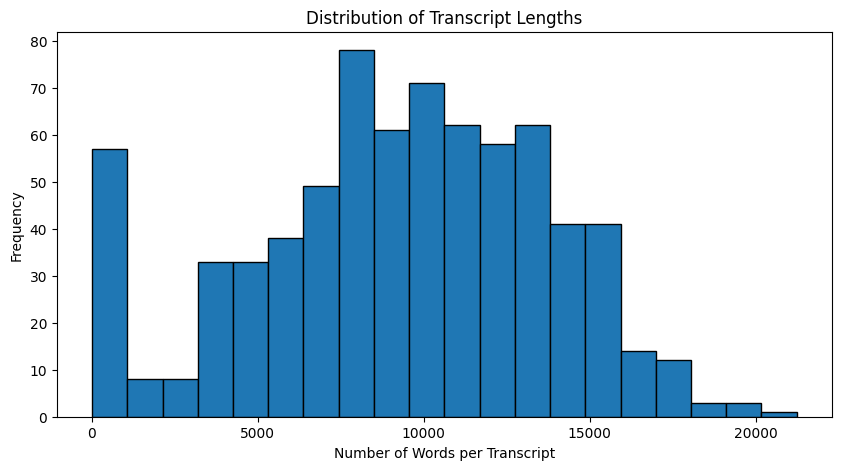

In [15]:
# Plot histogram of transcript lengths
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['Word Count'], bins=20, edgecolor='black')
plt.xlabel('Number of Words per Transcript')
plt.ylabel('Frequency')
plt.title('Distribution of Transcript Lengths')
plt.show

#### Key Observations:
- The distribution appears to be right-skewed, with a majority of transcripts falling within the 5,000 to 15,000-word range.
- There is a significant number of shorter transcripts (< 2,000 words), suggesting the presence of brief content.
- The most common transcript length appears to be around 8,000–10,000 words, as indicated by the highest frequency bars.
- There are a few exceptionally long transcripts (> 18,000 words), but they occur less frequently.



### Stop word removal using spaCy's built in stop word list & Lemmatization

In [16]:
import string
# Define additional custom stop words
custom_stopwords = {
    "yeah", "know", "right", "think", "people", "like", "um", "uh", "gonna", "gotta", "wanna",
    "okay", "said", "things", "way", "new", "got", "just", "really", "actually", "something", "thing",
    "kind", "sort", "maybe", "probably", "na", "gon", "podcast", "episode", "guy", "raz", "hey", "let", "stuff",
    "youre", "youve", "weve", "theyre", "theres", "whats", "doesnt", "isnt", "arent", "listen", "story", "moment",
    "point", "place", "lot", "day", "week", "month", "year","job",
    "business", "yes", "real", "long", "big", "huge", "early", "different", "understand", "guess", "way", "hard",
    "raise", "sit", "away", "free", "tell", "look","hmm", "call", "talk", "play", "come", "feel", "make", "give", "take", "end"
}

def clean_text (text):
    """
    Removes stop words, punctuation, and numbers from text.
    Applying lemmatization (word reduction)
    Filtering short words (<3 characters)    
    Args:
    - text (str): Input transcript text.
    
    Returns:
    - str: Cleaned text without stop words.
    """
    if not isinstance(text, str):
        return ""

    doc = nlp(text.lower())  # Convert to lowercase
    filtered_tokens = [
        token.lemma_  # Apply lemmatization
        for token in doc 
        if not token.is_stop  # Remove default stopwords
        and token.text not in custom_stopwords  # Remove custom stop words
        and token.text not in string.punctuation  # Remove punctuation
        and not token.text.isnumeric()  # Remove numbers
        and len(token.text) > 2  # Remove short words (e.g., "na", "ok")
    ]

    return " ".join(filtered_tokens)

# Apply stopword removal to cleaned transcript
df["Cleaned_Transcript"] = df["Cleaned_Transcript"].apply(clean_text)

### Word Cloud for Most Common Word

In [17]:
# Most Common Words
from collections import Counter

all_words = ' '.join(df['Cleaned_Transcript']).lower().split()
word_freq = Counter(all_words).most_common()
words, counts = zip(*word_freq)
print(word_freq)


[('go', 22820), ('mean', 22554), ('time', 20810), ('start', 19127), ('work', 17897), ('want', 15232), ('build', 15012), ('company', 13699), ('good', 10729), ('money', 9831), ('need', 9006), ('year', 8675), ('come', 8661), ('think', 8572), ('idea', 8489), ('try', 8419), ('sell', 8224), ('product', 8038), ('little', 7133), ('find', 6868), ('happen', 6596), ('great', 6592), ('brand', 6378), ('call', 6247), ('take', 6228), ('help', 6187), ('know', 5936), ('world', 5785), ('buy', 5736), ('make', 5706), ('remember', 5674), ('life', 5671), ('love', 5477), ('look', 5459), ('grow', 5422), ('store', 5190), ('guy', 5152), ('get', 4962), ('wow', 4825), ('run', 4768), ('million', 4719), ('pretty', 4718), ('today', 4485), ('see', 4426), ('food', 4387), ('friend', 4313), ('feel', 4194), ('talk', 4188), ('pay', 4093), ('kid', 4079), ('learn', 4065), ('school', 4035), ('ask', 4025), ('able', 3992), ('bring', 3972), ('say', 3946), ('basically', 3926), ('customer', 3915), ('create', 3899), ('bit', 3865),

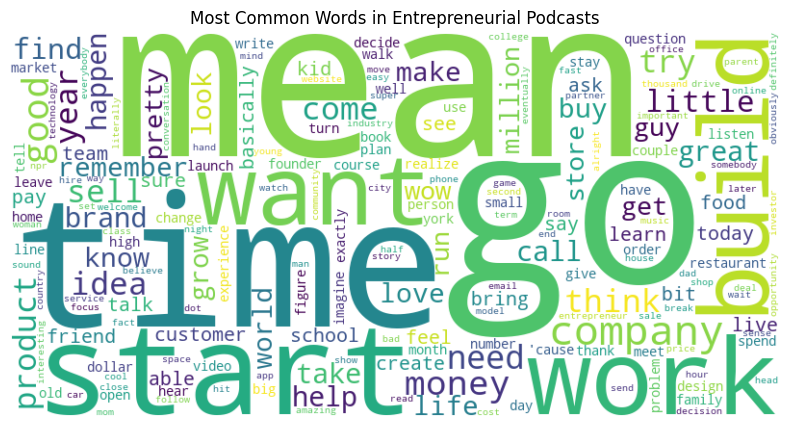

In [18]:
from wordcloud import WordCloud
# Convert to dictionary for WordCloud
word_freq_dict = dict(word_freq)  # FIX: Convert list to dictionary

# Generate WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Entrepreneurial Podcasts")
plt.show()

##### Success and Growth
"start," "build," "grow," "business," "company," "work"

These words indicate a strong focus on launching and scaling businesses.

Entrepreneurs frequently discuss starting a venture, building a brand, and strategies to grow.

#####  Ideas and Innovation
"idea," "product," "create," "develop," "market"

Entrepreneurship is heavily centered around innovation—turning an idea into a product and bringing it to market.

#####  Funding and Financials
"sell," "money," "invest," "need," "cost"

A crucial aspect of entrepreneurship is raising capital, selling products, and managing costs.

Investment discussions reflect the role of VCs, bootstrapping, and revenue models.

#####  Mindset and Decision-Making
"try," "happen," "decide," "risk," "change"

Entrepreneurship requires taking risks and embracing change.

Founders frequently discuss decision-making processes and the mindset needed to adapt.

#####  Time and Persistence
"time," "year," "long," "moment"

The journey to success often takes years, and entrepreneurs reflect on key moments that shaped their business.

#####  Networking and Relationships
"team," "friend," "partner," "family"

Entrepreneurs emphasize the importance of building strong teams, partnerships, and support networks.

### Business term count summary gives us key insights into how often business-related language appears in the podcast transcripts.

In [19]:
import seaborn as sns
# Business-related keywords
business_terms = [
    "profit", "revenue", "investment", "market", "customers", "growth", "strategy", "innovation", "risk", 
    "venture", "competition", "partnership", "sales", "branding", "marketing", "scaling", "product", "launch"
]

# Count occurrences of business terms
def count_business_terms(text):
    words = text.split()
    return sum(1 for word in words if word.lower() in business_terms)

df["Business_Term_Count"] = df["Cleaned_Transcript"].apply(count_business_terms)

# Check summary stats
print(df["Business_Term_Count"].describe())

count    733.000000
mean      32.560709
std       24.674231
min        0.000000
25%       14.000000
50%       28.000000
75%       48.000000
max      109.000000
Name: Business_Term_Count, dtype: float64


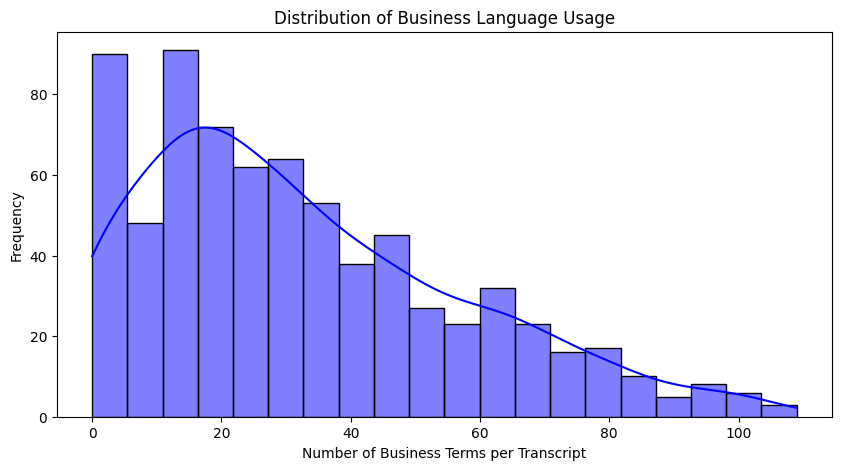

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(df["Business_Term_Count"], bins=20, kde=True, color="blue")
plt.xlabel("Number of Business Terms per Transcript")
plt.ylabel("Frequency")
plt.title("Distribution of Business Language Usage")
plt.show()

X-Axis (Number of Business Terms per Transcript)

This shows how many times business-related words (like profit, revenue, investment, market, growth) appear in each transcript.
Transcripts with fewer business terms (closer to 0) likely focus on personal stories or general advice rather than hardcore business concepts.
Transcripts with higher counts (closer to 100) are more business-heavy, possibly featuring investor discussions, financial strategies, or industry deep dives.

Y-Axis (Frequency)
This represents the number of transcripts that fall into each range of business term usage.
The most common transcripts contain between 10 and 30 business terms, indicating that business language is present but not always dominant.
A long tail exists, meaning a few transcripts use 80+ business terms, suggesting highly technical or finance-heavy discussions.
The Distribution Shape

The histogram is right-skewed, meaning most transcripts have lower business term usage, but some contain a high density of these terms.
The smooth KDE (Kernel Density Estimate) curve further confirms this trend, with a peak around 15-20 business terms per transcript.

## KMeans

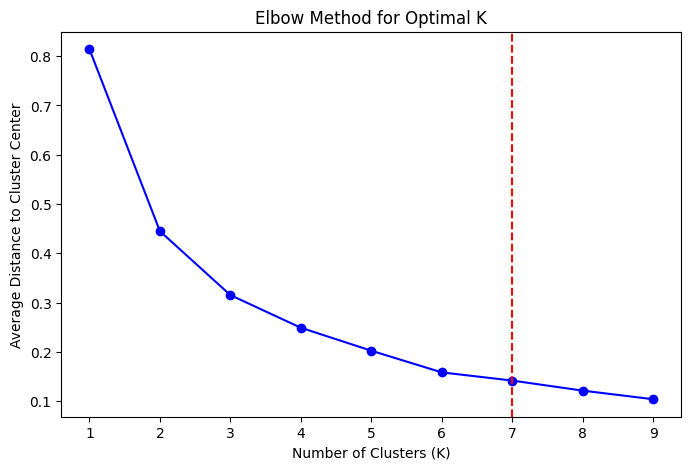

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

# Load Data (Assumes df["Business_Term_Count"] is already computed)
X = df[["Business_Term_Count"]].values

# Standardize the data (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the Elbow Method
distortions = []
K = range(1, 10)  # Checking for 1-10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=204, n_init=10)
    kmeans.fit(X_scaled)
    distortions.append(sum(np.min(cdist(X_scaled, kmeans.cluster_centers_, 'euclidean'), axis=1)) / X_scaled.shape[0])

# Find the optimal K using the "elbow" (second derivative method)
differences = np.diff(distortions, 2)  # Second-order difference
optimal_k = np.argmin(differences) + 2  # +2 to correct for indexing



# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K, distortions, 'bo-',  label="Distortion")
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K = {optimal_k}')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Average Distance to Cluster Center")
plt.title("Elbow Method for Optimal K")
plt.show()




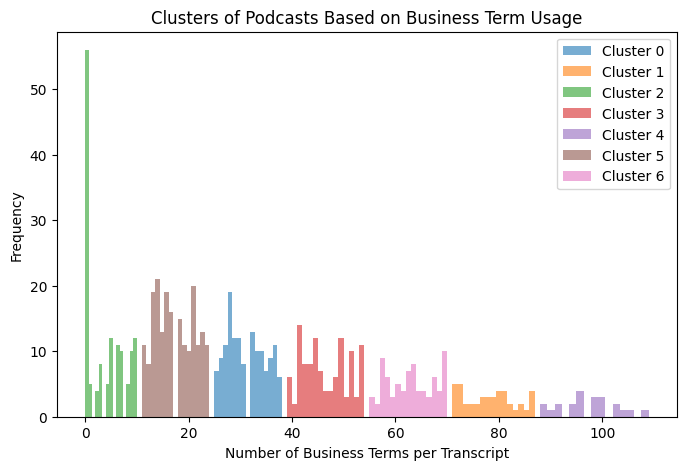

In [33]:
# Perform Clustering using Optimal K
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)
# Visualize the Clusters
plt.figure(figsize=(8, 5))
for cluster in range(optimal_k):
    plt.hist(df[df["Cluster"] == cluster]["Business_Term_Count"], bins=15, alpha=0.6, label=f"Cluster {cluster}")

plt.xlabel("Number of Business Terms per Transcript")
plt.ylabel("Frequency")
plt.title("Clusters of Podcasts Based on Business Term Usage")
plt.legend()
plt.show()

#### Cluster 2 (Green, Low Business Term Usage)

Dominates the 0-5 business term range.
Likely casual, non-business-focused episodes (e.g., personal stories, general discussions).

#### Clusters 5 & 0 (Brown & Blue, Moderate Business Term Usage)

Fall in the 10-40 range.
Likely a mix of entrepreneurship and personal experience discussions.

#### Clusters 3 & 6 (Red & Pink, Business-Focused)
Range: 40-70 business terms.
Likely feature detailed business strategies, market discussions, and finance-heavy content.


#### Cluster 1 & 4 (Orange & Purple, High Business Term Usage)

Range: 70-110 business terms.
These are intensely business-driven episodes (e.g., deep dives into funding, financial models, marketing, or case studies).

- Podcasts naturally segment into different business content intensities.
- Most episodes fall into the low-to-moderate business term range.
- A smaller number of transcripts are highly technical or finance-heavy.



### How often industry & financial terms appear

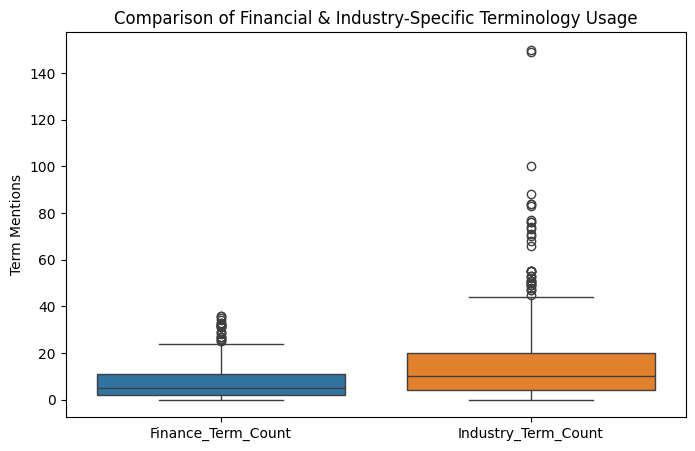

In [22]:
# Industry & finance-related terms
finance_terms = ["funding", "investment", "capital", "equity", "profit", "loss", "valuation", "shareholders", "revenue"]
industry_terms = ["technology", "fashion", "food", "software", "retail", "health", "ecommerce", "finance", "manufacturing"]

def count_terms(text, term_list):
    words = text.split()
    return sum(1 for word in words if word.lower() in term_list)

df["Finance_Term_Count"] = df["Cleaned_Transcript"].apply(lambda x: count_terms(x, finance_terms))
df["Industry_Term_Count"] = df["Cleaned_Transcript"].apply(lambda x: count_terms(x, industry_terms))

# Plot industry-specific vs. finance terms
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["Finance_Term_Count", "Industry_Term_Count"]])
plt.ylabel("Term Mentions")
plt.title("Comparison of Financial & Industry-Specific Terminology Usage")
plt.show()

Finance terms (left box plot) are less frequently mentioned compared to industry-specific terms.
Most discussions are industry-focused rather than finance-heavy

### Challenges Vs Success

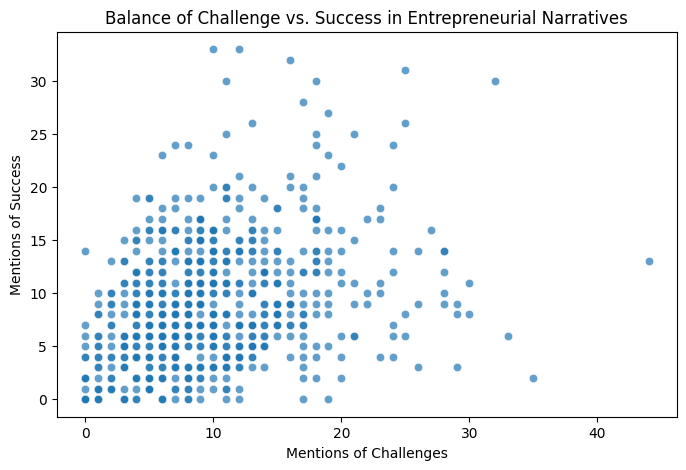

In [23]:
# Define success and challenge keywords
challenge_terms = ["challenge", "difficult", "problem", "struggle", "hard", "failure", "obstacle"]
success_terms = ["growth", "success", "achieve", "win", "scale", "expand", "profit", "breakthrough"]

df["Challenge_Count"] = df["Cleaned_Transcript"].apply(lambda x: count_terms(x, challenge_terms))
df["Success_Count"] = df["Cleaned_Transcript"].apply(lambda x: count_terms(x, success_terms))

# Plot challenge vs success discussions
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Challenge_Count"], y=df["Success_Count"], alpha=0.7)
plt.xlabel("Mentions of Challenges")
plt.ylabel("Mentions of Success")
plt.title("Balance of Challenge vs. Success in Entrepreneurial Narratives")
plt.show()


Most data points fall between 0-20 mentions of challenges.
There is a positive correlation, meaning that podcasts mentioning more challenges also tend to mention more successes—suggesting a storytelling pattern where struggles lead to success.

A few outliers exist, such as a high-challenge, low-success point this could represent stories of businesses that struggled without major wins.

This reinforces the idea that resilience is a core theme in entrepreneurship.

#### Different types of entrepreneurial journeys emerge:

Low Challenge, High Success: Likely seasoned entrepreneurs or success-story-focused episodes.

High Challenge, Low Success: Likely failures or hard lessons in startups.

Balanced Challenge & Success: Typical founder journeys, discussing both struggles and wins.


# Sentiment Analysis

Apply VADER to analyze the emotional tone of each transcript.

In [24]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment scores
def get_sentiment(text):
    if not isinstance(text, str):  # Handle missing values
        return 0  
    return analyzer.polarity_scores(text)['compound']

# Apply sentiment analysis to transcripts
df["Sentiment Score"] = df["Cleaned_Transcript"].apply(get_sentiment)

# Categorize into Positive, Neutral, Negative
df["Sentiment Label"] = df["Sentiment Score"].apply(lambda x: "Positive" if x > 0.05 else "Negative" if x < -0.05 else "Neutral")

# Show sentiment distribution
print(df["Sentiment Label"].value_counts())



Sentiment Label
Positive    685
Negative     48
Name: count, dtype: int64


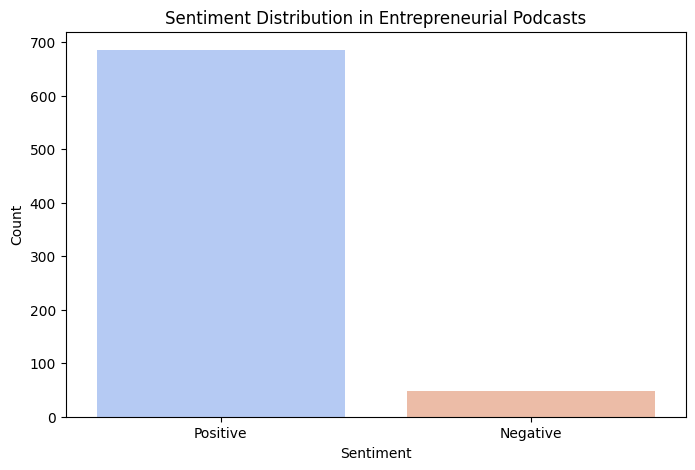

In [25]:
# Plot sentiment distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Sentiment Label", hue="Sentiment Label", palette="coolwarm", legend=False)  # FIXED
plt.title("Sentiment Distribution in Entrepreneurial Podcasts")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Entrepreneurial podcasts are overwhelmingly positive

This could mean entrepreneurs focus more on growth, success, and motivation rather than struggles.

Very few episodes focus on failures, obstacles, or negativity.

Entrepreneurs likely frame struggles as learning experiences rather than failures.

Possible Bias in the Data? This suggests that only successful entrepreneurs (or those with uplifting stories) tend to get featured.

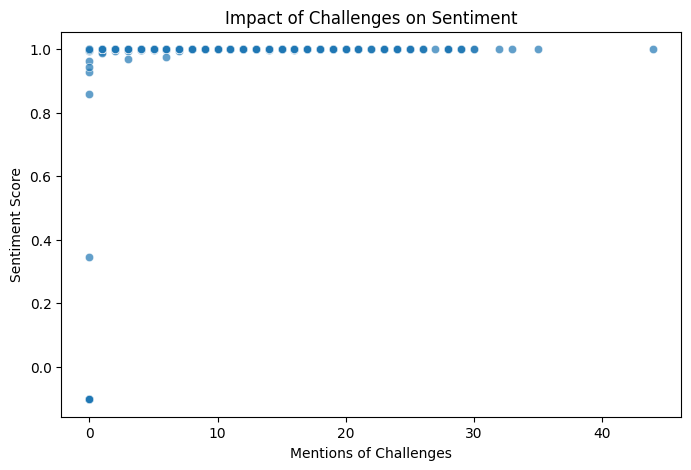

In [26]:
# Scatter plot of Challenge Count vs. Sentiment Score
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Challenge_Count"], y=df["Sentiment Score"], alpha=0.7)
plt.xlabel("Mentions of Challenges")
plt.ylabel("Sentiment Score")
plt.title("Impact of Challenges on Sentiment")
plt.show()


Key Observations
Highly Positive Sentiment Despite Challenges

Most data points are clustered near 1.0 (positive sentiment score), even when challenges are mentioned frequently.
This suggests that entrepreneurs often frame challenges in an optimistic, problem-solving manner.
Few Low-Sentiment Points (Near 0)

A few data points have sentiment scores closer to 0.0 (neutral or negative).
These could be episodes that focus on failures, struggles, or setbacks without immediate resolution.
No Clear Negative Correlation

More mentions of challenges do not lower sentiment scores.
Entrepreneurs likely share struggles but emphasize growth, learning, and success.

Key Takeaways
- Challenges are reframed as learning experiences.

The dominant positive sentiment suggests that even hardship-focused discussions are ultimately motivational.
- Entrepreneurs tell resilience-driven stories.

Even transcripts with high challenge mentions (30+ times) still maintain positive sentiment.
- Possible Bias in Entrepreneurship Podcasts?

If challenges were framed more negatively, we’d expect a stronger downward trend in sentiment.
This suggests entrepreneurial storytelling tends to highlight victories over struggles.

 Keyword Extraction for Key Themes

TF-IDF for Key Business Terms to extract important words & phrases from transcripts

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text into TF-IDF vectors
vectorizer = TfidfVectorizer(stop_words="english", max_features=50, ngram_range=(1,2))  
X = vectorizer.fit_transform(df["Cleaned_Transcript"])

# Get top keywords
top_keywords = vectorizer.get_feature_names_out()
print("Top Keywords Extracted:", top_keywords)


Top Keywords Extracted: ['able' 'ask' 'brand' 'build' 'buy' 'cause' 'com' 'come' 'company' 'feel'
 'food' 'friend' 'good' 'great' 'grow' 'guy' 'happen' 'help' 'idea' 'kid'
 'know' 'learn' 'life' 'little' 'look' 'love' 'make' 'mean' 'million'
 'money' 'need' 'pay' 'pretty' 'product' 'remember' 'run' 'school' 'sell'
 'start' 'store' 'talk' 'think' 'time' 'today' 'try' 'want' 'work' 'world'
 'wow' 'year']


 Key Observations
 
 Business & Strategy Keywords:

'brand', 'build', 'business', 'buy', 'company', 'product', 'sell', 'start', 'store'
Suggests strong focus on building businesses, branding, and sales.
"Start" being a top word aligns with entrepreneurial journeys from launch to growth.

Financial & Growth Terms:

'money', 'make', 'need'
Indicates that entrepreneurs frequently discuss finances, capital, and funding strategies.

Personal & Motivational Words:

'idea', 'help', 'life', 'love', 'think', 'time', 'try', 'want', 'work', 'world'
This highlights passion-driven discussions, reflecting the emotional aspect of entrepreneurship.
"Try", "want", "think" suggest that entrepreneurs emphasize innovation, problem-solving, and ambition.

Emotional & Conversational Words:

'great', 'good', 'wow', 'thank', 'yes', 'listen', 'tell', 'talk'
Reinforces that these podcasts have a positive & conversational tone, matching the sentiment analysis results.

## Recommendations & Conclusions

### Summary of Findings  
From the analysis of **entrepreneurial podcast transcripts**, we identified key themes in storytelling, sentiment, and business language usage. The main takeaways include:  

1. **Entrepreneurial storytelling is highly positive**  
   - Despite frequent mentions of **challenges**, sentiment remains **overwhelmingly positive**—indicating that **entrepreneurs frame hardships as learning experiences** rather than failures.  

2. **Business term density varies across episodes**  
   - We identified **distinct clusters** of podcasts:
     - **Low-business term clusters** → More personal storytelling & casual discussions.  
     - **Mid-level clusters** → A balance of business insights and motivational content.  
     - **High-business term clusters** → Deep dives into **strategy, investment, and financials**.  

3. **Keyword analysis revealed a strong focus on growth & learning**  
   - Common themes include **building brands, growing companies, learning from experiences, and financial success.**  
   - The presence of **casual words** (e.g., *“hey,” “wow,” “friend”*) suggests that these conversations are **engaging and informal** rather than strictly business-like.  


### Challenges Faced in the Analysis  
1. **Handling Noise in Text Data**  
   - Some words like **“com”** or **host names (e.g., Guy Raz)** were **not meaningful** but still appeared in early keyword extractions. We refined our **stopword list** to improve accuracy.  

2. **Subjectivity in Sentiment Analysis**  
   - **Positive bias** in sentiment scores → Many challenges were framed positively, making it harder to distinguish **true negative sentiment**. A **more advanced NLP model** (like fine-tuned BERT) could improve accuracy.  

3. **Determining Optimal Clusters**  
   - Finding the **right number of clusters (K) for K-Means** required multiple iterations. We used the **Elbow Method**, but more sophisticated clustering (like DBSCAN or Hierarchical Clustering) could be explored.  



## Future Improvements

To enhance our analysis and provide deeper insights, we can expand on the following areas:

### Expand Dataset Size and Sources  
- Incorporate more **podcast transcripts** from different sources, including **YouTube, TED Talks, and industry-specific discussions**.  
- Increase diversity in **industries and business models** covered in the dataset.  

### Advance Topic Modeling 
- Move beyond simple keyword extraction by implementing **Latent Dirichlet Allocation (LDA)** or **BERT-based topic modeling**.  
- Automatically classify podcasts into **entrepreneurial themes** such as funding, branding, scaling, and leadership.  

### Implement Advanced ML Models 
- Train **sentiment analysis models** on domain-specific data to improve accuracy.  
- Use **deep learning (transformers like GPT/BERT)** to detect nuanced business strategies.  
- Explore **predictive modeling** for identifying podcast success factors.  

### Create Interactive Visualization Tools 
- Develop **dashboard visualizations** using **Plotly or Streamlit** for real-time data exploration.  
- Allow users to **filter and compare podcast insights** based on keywords, sentiment, and business term density. 

### Develop a Recommendation System
- Build a **podcast episode recommendation engine** that suggests content based on user preferences.  
- Leverage **collaborative filtering and NLP-based similarity analysis**.  

### Build Automated Insight Generation  
- Implement **NLP-based summarization** to generate key takeaways from podcast transcripts.  
- Develop a system that **automatically extracts trends and success patterns**.  


## Conclusion
By incorporating these improvements, we can **unlock deeper insights** into entrepreneurial storytelling, improve **predictive analytics**, and create **valuable tools for aspiring entrepreneurs and researchers**. 

